<a href="https://colab.research.google.com/github/BerzanBaran/amazon-review-sentiment-analysis/blob/main/gorev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Amazon Ürün Yorumları — Duygu Analizi

In [3]:
#Kütüphaneler
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from wordcloud import WordCloud
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("Tüm kütüphaneler yüklendi")

Tüm kütüphaneler yüklendi


Sınıf Dağılımı:
sentiment
positive    4448
negative     324
neutral      142
Name: count, dtype: int64

Toplam yorum sayısı: 4914


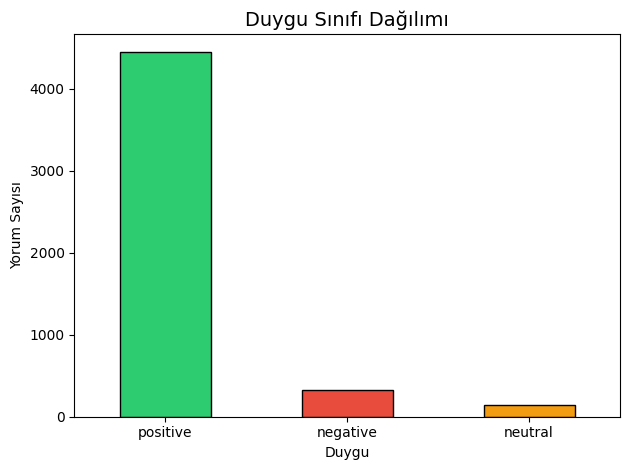

In [4]:
#Veri Yükleme
df = pd.read_csv("amazon_review.csv")

#Etiket türetme
def get_sentiment(rating):
    if rating >= 4:     #4–5 yıldız → Positive
        return "positive"
    elif rating == 3: #3 yıldız →Neutral
        return "neutral"
    else:        #1–2 yıldız →Negative
        return "negative"

df['sentiment'] = df['overall'].apply(get_sentiment)

#Eksik reviewText satırlarını düşür
df = df.dropna(subset=['reviewText']).reset_index(drop=True)

#Sınıf dağılımı
print("Sınıf Dağılımı:")
print(df['sentiment'].value_counts())
print(f"\nToplam yorum sayısı: {len(df)}")

#Görselleştirme
colors = ['#2ecc71', '#e74c3c', '#f39c12']
df['sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title("Duygu Sınıfı Dağılımı", fontsize=14)
plt.xlabel("Duygu")
plt.ylabel("Yorum Sayısı")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
#Metin Ön İşleme
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    #İfadeyi küçük harfe çevir
    text = text.lower()
    #URL temizle
    text = re.sub(r'http\S+', '', text)
    #Noktalama ve rakamları temizle
    text = re.sub(r'[^a-z\s]', '', text)
    #Fazla boşlukları temizle
    text = re.sub(r'\s+', ' ', text).strip()
    #Tokenization ve Stop-word temizle ve Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df['clean_text'] = df['reviewText'].apply(preprocess)

#Önce ve sonra karşılaştırması
print("Örnek Ön İşleme Sonucu")
for i in range(3):
    print(f"\n[{i+1}] Ham metin:\n  {df['reviewText'].iloc[i][:120]}")
    print(f"  Temizlenmiş:\n  {df['clean_text'].iloc[i][:120]}")

Örnek Ön İşleme Sonucu

[1] Ham metin:
  No issues.
  Temizlenmiş:
  issue

[2] Ham metin:
  Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot 
  Temizlenmiş:
  purchased device worked advertised never much phone memory since download lot stuff brainer

[3] Ham metin:
  it works as expected. I should have sprung for the higher capacity.  I think its made a bit cheesier than the earlier ve
  Temizlenmiş:
  work expected sprung higher capacity think made bit cheesier earlier version paint look clean


In [6]:
#TF-IDF Vektörizasyon
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),   #unigram + bigram → daha iyi bağlam
    sublinear_tf=True     #log ölçekleme, sık kelimelerin baskısını azaltır
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

#Model 1: LinearSVC
svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
svm.fit(X_train_vec, y_train)
svm_preds = svm.predict(X_test_vec)

#Model 2: Logistic Regression (karşılaştırma)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_vec, y_train)
lr_preds = lr.predict(X_test_vec)

#Sonuçlar
print("=" * 55)
print("LinearSVC Sonuçları:")
print("=" * 55)
print(classification_report(y_test, svm_preds, target_names=['negative','neutral','positive']))

print("=" * 55)
print("Logistic Regression Sonuçları:")
print("=" * 55)
print(classification_report(y_test, lr_preds, target_names=['negative','neutral','positive']))

LinearSVC Sonuçları:
              precision    recall  f1-score   support

    negative       0.79      0.58      0.67        65
     neutral       0.00      0.00      0.00        28
    positive       0.95      0.99      0.97       890

    accuracy                           0.93       983
   macro avg       0.58      0.52      0.55       983
weighted avg       0.91      0.93      0.92       983

Logistic Regression Sonuçları:
              precision    recall  f1-score   support

    negative       0.61      0.75      0.68        65
     neutral       0.10      0.07      0.08        28
    positive       0.97      0.96      0.96       890

    accuracy                           0.92       983
   macro avg       0.56      0.59      0.57       983
weighted avg       0.92      0.92      0.92       983



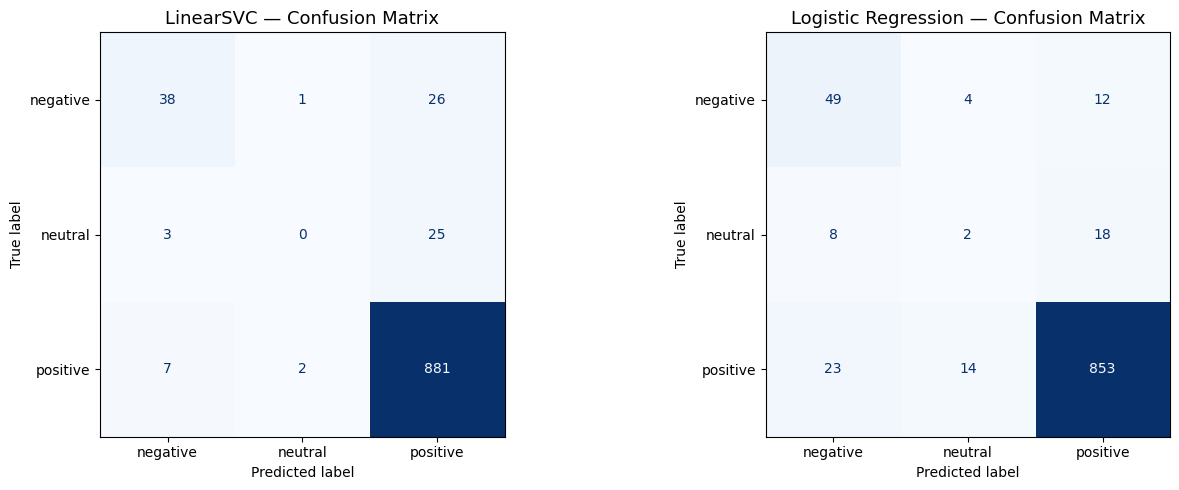

In [7]:
#Confusion Matrix (LinearSVC)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [svm_preds, lr_preds],
                             ["LinearSVC", "Logistic Regression"]):
    cm = confusion_matrix(y_test, preds, labels=['negative', 'neutral', 'positive'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'neutral', 'positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{title} — Confusion Matrix", fontsize=13)

plt.tight_layout()
plt.show()

En Çok Şikayet Edilen 5 Anahtar Kelime:
   keyword  tfidf_score
1     card    79.567412
2    phone    36.974383
3  sandisk    33.841399
4    month    27.147244
5      one    23.602541


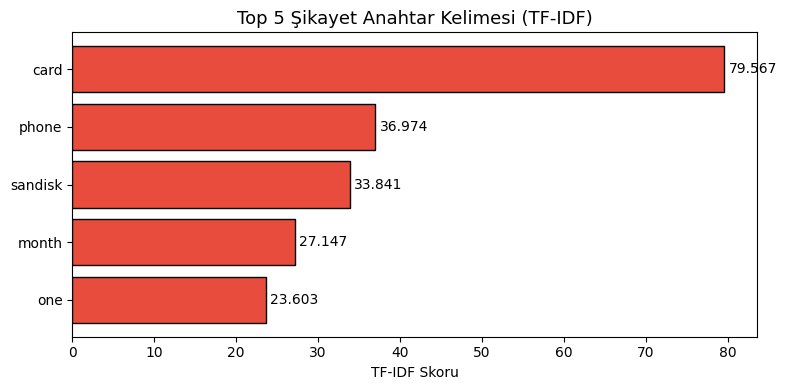

In [8]:
#En Çok Şikayet Edilen 5 Anahtar Kelime
negative_texts = df[df['sentiment'] == 'negative']['clean_text']

tfidf_neg = TfidfVectorizer(max_features=50, ngram_range=(1, 1))
neg_matrix = tfidf_neg.fit_transform(negative_texts)

scores = np.array(neg_matrix.sum(axis=0)).flatten()
keywords = tfidf_neg.get_feature_names_out()

neg_df = pd.DataFrame({'keyword': keywords, 'tfidf_score': scores})
top5 = neg_df.sort_values('tfidf_score', ascending=False).head(5).reset_index(drop=True)
top5.index += 1

print("En Çok Şikayet Edilen 5 Anahtar Kelime:")
print("=" * 35)
print(top5.to_string())

#Görselleştirme
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5['keyword'][::-1], top5['tfidf_score'][::-1], color='#e74c3c', edgecolor='black')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title("Top 5 Şikayet Anahtar Kelimesi (TF-IDF)", fontsize=13)
ax.set_xlabel("TF-IDF Skoru")
plt.tight_layout()
plt.show()

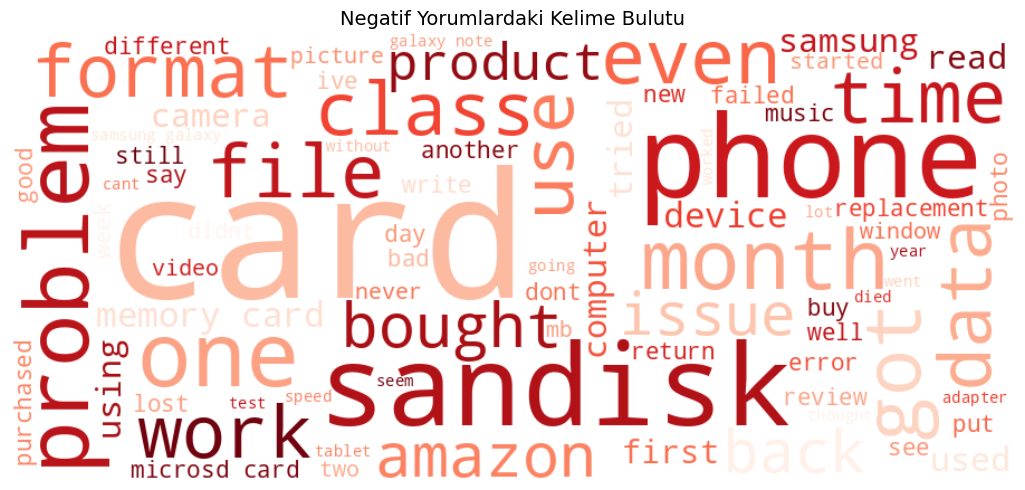

In [ ]:
#Negatif Yorum WordCloud
neg_corpus = " ".join(negative_texts)

wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='Reds',
    max_words=80
).generate(neg_corpus)

plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Negatif Yorumlardaki Kelime Bulutu", fontsize=14)
plt.tight_layout()
plt.show()